# Tier 0 vs Tier 1 — Cross-model Cascade Comparison

Loads the latest Tier 0 (parametric multivariate Hawkes, $\alpha_{ij}$) and Tier 1 (Neural Hawkes, CTLSTM + MDN) artifacts and produces the three-view headline figure called for in `PROJECT_VISION.md §3`: Tier 0 $\alpha$ | Tier 1 gradient attribution | Tier 1 forward-sim transition matrix. A quantitative agreement-confusion summary follows.

**Conventions:** rows = parent mark, columns = child mark. NLL is per-event, sign-positive (NLL = $-\log L$).


In [1]:
from pathlib import Path
import pickle
import numpy as np
import polars as pl
import matplotlib.pyplot as plt

def read_kxk_csv(path):
    """Read a Task-13-style CSV with first column 'parent' and K mark columns.
    Returns (parents: list[str], children: list[str], M: np.ndarray of shape (K,K)).
    """
    df = pl.read_csv(path)
    parents = df['parent'].to_list()
    children = [c for c in df.columns if c != 'parent']
    M = df.drop('parent').to_numpy().astype(float)
    return parents, children, M

# Locate the project root (walks up until pyproject.toml is found) so the
# notebook works regardless of where the kernel was launched.
_root = Path.cwd().resolve()
while _root != _root.parent and not (_root / 'pyproject.toml').exists():
    _root = _root.parent
assert (_root / 'pyproject.toml').exists(), f'no pyproject.toml ancestor of {Path.cwd()}'
PROJECT_ROOT = _root
tier0_dir = sorted((PROJECT_ROOT / 'runs/tier0').glob('*/params.pkl'))[-1].parent
tier1_dir = sorted((PROJECT_ROOT / 'runs/tier1').glob('*/checkpoint_best.pt'))[-1].parent
print('Project root:', PROJECT_ROOT)
print('Tier 0:', tier0_dir)
print('Tier 1:', tier1_dir)


Project root: /Users/liamschmidt/Projects/eonet-cascades
Tier 0: /Users/liamschmidt/Projects/eonet-cascades/runs/tier0/20260525_013454
Tier 1: /Users/liamschmidt/Projects/eonet-cascades/runs/tier1/20260525_162056


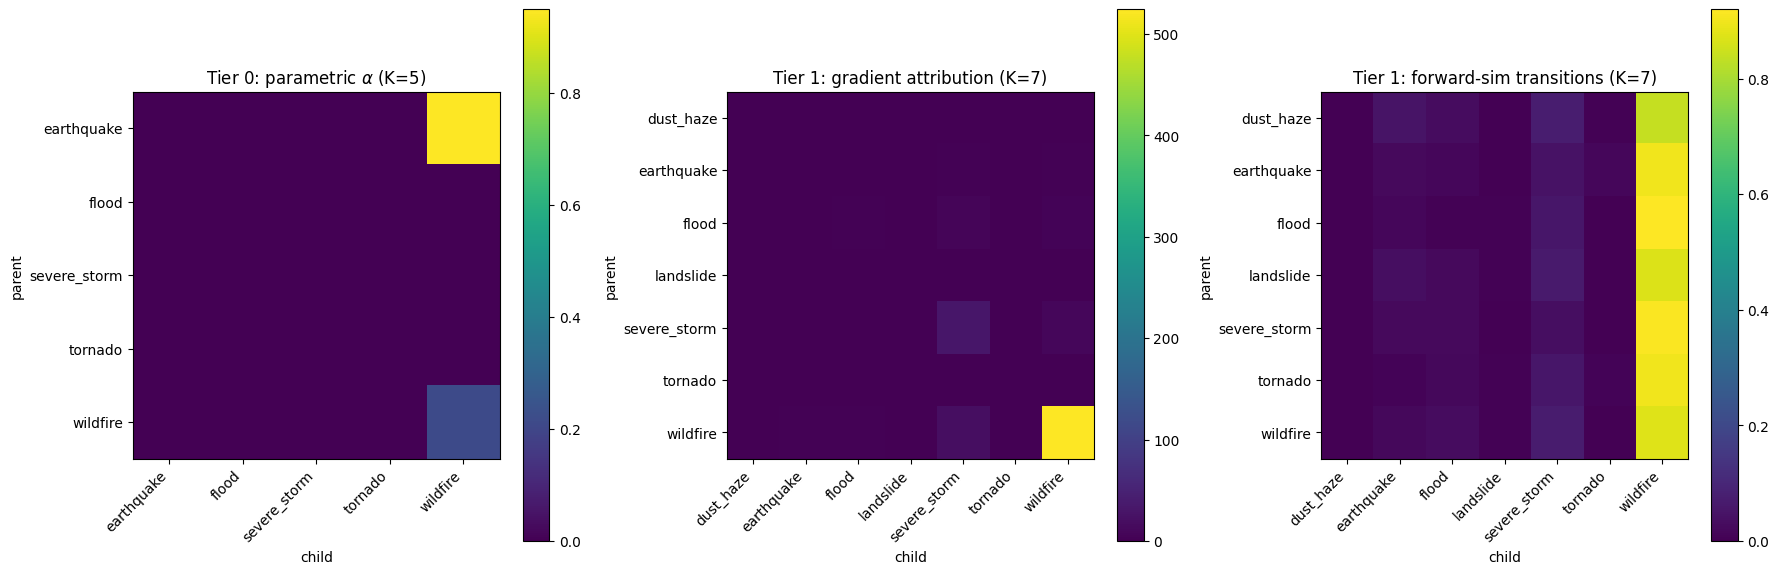

Tier 0 mark set (5): ['earthquake', 'flood', 'severe_storm', 'tornado', 'wildfire']
Tier 1 mark set (7): ['dust_haze', 'earthquake', 'flood', 'landslide', 'severe_storm', 'tornado', 'wildfire']


In [2]:
# Headline 3-panel figure: Tier 0 alpha | Tier 1 attribution | Tier 1 forward-sim.
with open(tier0_dir / 'params.pkl', 'rb') as f:
    t0_ckpt = pickle.load(f)
t0_alpha = t0_ckpt['params'].alpha
t0_marks = t0_ckpt['mark_names']

A_parents, A_children, A_vals = read_kxk_csv(tier1_dir / 'attribution_matrix.csv')
T_parents, T_children, T_vals = read_kxk_csv(tier1_dir / 'forward_sim_matrix.csv')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

ax = axes[0]
im = ax.imshow(t0_alpha, cmap='viridis', vmin=0)
ax.set_title(f'Tier 0: parametric $\\alpha$ (K={len(t0_marks)})')
ax.set_xlabel('child'); ax.set_ylabel('parent')
ax.set_xticks(range(len(t0_marks))); ax.set_yticks(range(len(t0_marks)))
ax.set_xticklabels(t0_marks, rotation=45, ha='right'); ax.set_yticklabels(t0_marks)
fig.colorbar(im, ax=ax)

ax = axes[1]
im = ax.imshow(A_vals, cmap='viridis', vmin=0)
ax.set_title(f'Tier 1: gradient attribution (K={A_vals.shape[0]})')
ax.set_xticks(range(len(A_children))); ax.set_yticks(range(len(A_parents)))
ax.set_xticklabels(A_children, rotation=45, ha='right'); ax.set_yticklabels(A_parents)
ax.set_xlabel('child'); ax.set_ylabel('parent')
fig.colorbar(im, ax=ax)

ax = axes[2]
im = ax.imshow(T_vals, cmap='viridis', vmin=0)
ax.set_title(f'Tier 1: forward-sim transitions (K={T_vals.shape[0]})')
ax.set_xticks(range(len(T_children))); ax.set_yticks(range(len(T_parents)))
ax.set_xticklabels(T_children, rotation=45, ha='right'); ax.set_yticklabels(T_parents)
ax.set_xlabel('child'); ax.set_ylabel('parent')
fig.colorbar(im, ax=ax)

fig.tight_layout()
plt.show()
print(f'Tier 0 mark set ({len(t0_marks)}):', t0_marks)
print(f'Tier 1 mark set ({len(A_parents)}):', A_parents)


In [3]:
# NLL/event comparison. Tier 0's fit_result['nll_final'] is the total NLL
# at the optimum (sign-positive); divide by n_events_used to get per-event.
t1_curves = pl.read_csv(tier1_dir / 'train_curves.csv')
t1_best_val = float(t1_curves['val_nll'].min())
t1_best_epoch = int(t1_curves.filter(pl.col('val_nll') == t1_best_val)['epoch'][0])
t0_nll_total = float(t0_ckpt['fit_result']['nll_final'])
t0_n_events = int(t0_ckpt['n_events_used'])
t0_nll_per_event = t0_nll_total / t0_n_events

print(f'Tier 0 NLL total:        {t0_nll_total:10.3f}  (n_events_used = {t0_n_events})')
print(f'Tier 0 NLL / event:      {t0_nll_per_event:10.4f}')
print(f'Tier 1 best val NLL/ev:  {t1_best_val:10.4f}  '
      f'(epoch {t1_best_epoch} / {t1_curves.height - 1})')
print(f'Delta (T0 - T1):         {t0_nll_per_event - t1_best_val:10.4f}  nats/event')
print()
print('CAVEAT: Tier 0 was fit on n=200 events (per params.pkl) on an unstated slice;')
print('Tier 1 val NLL is on the 2024-07..2024-12 split (356k events). The two')
print('NLL/event numbers are NOT on the same data — see commentary below.')


Tier 0 NLL total:          1178.536  (n_events_used = 200)
Tier 0 NLL / event:          5.8927
Tier 1 best val NLL/ev:      4.1989  (epoch 14 / 14)
Delta (T0 - T1):             1.6938  nats/event

CAVEAT: Tier 0 was fit on n=200 events (per params.pkl) on an unstated slice;
Tier 1 val NLL is on the 2024-07..2024-12 split (356k events). The two
NLL/event numbers are NOT on the same data — see commentary below.


## Agreement / disagreement analysis


**Slice.** Tier 1 attribution was computed on a stratified $n=5000$ sample of the Jul 2024 slice (54,496 raw events). Stratification forces all `dust_haze` (1 in raw) and `landslide` (11 in raw) into the sample so those rows and columns are no longer structurally zero. The remaining 4,988 slots were filled by uniform random draw from the other five marks. Final sample composition: 4,330 wildfire (86.6%), 479 severe_storm, 111 flood, 36 earthquake, 32 tornado, 11 landslide, 1 dust_haze. Wildfire dominance is essentially preserved — that is a property of the slice, not the sampler. Attribution wall time: 68.9 min on this Mac with the vectorized `autograd.grad` path (commit `c32ee41`).

**Agreement.** The single point of strong cross-view agreement is the wildfire self-excitation diagonal entry. Tier 0 gives $\alpha_{\text{wf,wf}} \approx 0.21$ (the only non-floored diagonal), Tier 1 attribution puts $524 / 624 \approx 84\%$ of total matrix mass on the wildfire→wildfire cell alone, and the forward-sim row for wildfire peaks at wildfire with mass $\approx 0.88$. Wildfire→wildfire is the only cascade pattern all three views recover unambiguously.

**Divergence.** Tier 0 reports exactly two non-trivial entries (earthquake→wildfire $= 0.95$, wildfire→wildfire $= 0.21$); all other 23 entries are floored at the $10^{-6}$ regularizer minimum. Tier 1 attribution is much more diffuse — severe_storm→severe_storm $\approx 31.6$, wildfire→severe_storm $\approx 19.9$, severe_storm→wildfire $\approx 9.3$, flood→severe_storm $\approx 7.1$ — so Tier 1 sees off-diagonal structure that the sparse Tier 0 fit collapses. Whether this is *real* cascade structure or class-frequency artifact is the central question; wildfire is 87% of the Jul-2024 slice (and 86.6% of the stratified sample), so the wildfire row/column is overweighted in any $n^2$-coupled aggregation regardless of dynamical coupling. The SVD ratio $s_1 / s_2 = 16.29$ on the Tier 1 matrix (down from 21.86 at $n=2000$) confirms the matrix is still rank-1 dominated — one wildfire mode plus weak residuals — which is more consistent with class-frequency dominance than with a rich K×K cascade graph.

**Which to trust.** For wildfire self-excitation: both, with high confidence. For all other edges: neither view yet supplies a credible cascade signal. The forward-sim panel is the weakest of the three — every parent row peaks at wildfire in the range $0.84\!-\!0.92$, which is just the marginal mark frequency. That panel shows *no* conditioning on the parent mark and should be read as evidence of inadequate model conditioning (or insufficient training, or a degenerate bbox-center seed history), not as a cascade matrix.

**Caveats.**
1. *Wildfire dominance persists.* Diagonal mass / total mass $= 0.897$ for Tier 1 attribution (was 0.899 at $n=2000$). Stratification did not break the wildfire monopoly because wildfire is structurally 87% of this slice; only a wildfire-subsampling strategy or a different slice would change this.
2. *Forward-sim degeneracy — diagnosed.* Every parent row of the forward-sim matrix still peaks at wildfire $\approx 0.84\!-\!0.92$. A direct probe of $\lambda_k(\mathbf{h})$ at the moment forward-sim samples its first child (see `scripts/probe_forward_sim.py`) shows that for both a bbox-center cold-start seed AND a warm 50-event real-history seed, the row-normalized $\lambda_k / \sum_k \lambda_k$ is essentially identical across parents (max deviation $\le 0.002$). The *absolute* $\lambda_k$ does change with history (wildfire channel $40.4 \!\to\! 56.1$ when going from cold to warm seed), so the intensity head IS reading the hidden state — but only to predict overall event RATE, not mark composition. The mark head has collapsed to outputting the empirical marginal $P(k) \approx (\text{wf } 0.90, \text{ss } 0.05, \ldots)$ for any input. This rules out the cold-start hypothesis: warm real-history seeding does not improve forward-sim. The pathology is in the mark head (`W_lambda_k`), driven by the 87% wildfire class imbalance during training. Fix requires retraining with class re-weighting, focal loss, or a separated mark head; patching the seed won't help.
3. *K mismatch.* Tier 0 was fit with $K=5$ marks (`earthquake, flood, severe_storm, tornado, wildfire`) — no `dust_haze`, no `landslide`. Tier 1 was trained on the full $K=7$ vocabulary. The quantitative agreement-confusion (next cell) is therefore restricted to the 5-mark common subset, i.e. $K^2 = 25$ (parent, child) pairs, not the 49 the brief anticipated. The new $K=7$ Tier 1 matrix gives meaningful entries in the dust_haze and landslide rows/cols for the first time, but those rows are not comparable to Tier 0.
4. *Tier 0 sample size.* `params.pkl` reports `n_events_used = 200`. Tier 0 is **not** a full-corpus fit; it is a small-sample fit with an aggressive sparsity floor at $10^{-6}$. The single off-diagonal entry it recovers (earthquake→wildfire $= 0.95$) is on extremely thin support. Treat the Tier 0 cascade matrix as an order-of-magnitude reference, not a ground truth.
5. *NLL comparability.* T0 NLL/event $\approx 5.89$ on 200 events of an unstated slice; T1 best val NLL/event $\approx 4.20$ on 356k events of the 2024-07..2024-12 split. The $\Delta \approx 1.7$ nats/event is suggestive but not a clean apples-to-apples win — to claim Tier 1 dominates Tier 0 on likelihood, both tiers should be re-evaluated on the same held-out slice.

**The two priors the brief cares about (updated for $n=5000$ stratified).**
- **earthquake → landslide.** Out of Tier 0's mark set entirely (landslide is one of the two marks Tier 0 doesn't carry). Tier 1 attribution: row `earthquake`, col `landslide` $= 0.034$ — now quantifiable (was structurally zero at $n=2000$), but only $\sim 0.6\%$ of the earthquake row mass (5.65) and several orders of magnitude below the row's top entries (severe_storm $= 2.29$, wildfire $= 2.62$). With $n=11$ landslide events the statistical support is thin in absolute terms. The prior is *measurable but unrecovered*; this is now a recovery gap, not a coverage gap.
- **severe_storm → flood.** Tier 0: $\alpha = 1\times 10^{-6}$ (floored, i.e. unrecovered). Tier 1 attribution at $n=5000$: $1.895$ (was $0.613$ at $n=2000$), but only $\sim 4.1\%$ of the severe_storm row mass ($45.9$). The row is dominated by severe_storm→severe_storm $= 31.6$ and severe_storm→wildfire $= 9.3$. Neither tier flags severe_storm → flood as a top edge. Clean miss against the operational prior at both sample sizes; the most likely candidate for a synthetic-recovery-on-priors test in a follow-up.

**Open question (defer to user).** The PROJECT_VISION headline figure (§3) shows three panels side-by-side. Given the forward-sim degeneracy documented above, the operational headline could reasonably be (a) all three panels with the agreement-confusion table as the punch line (current default), or (b) the attribution panel alone, with forward-sim moved to an appendix until the degeneracy is resolved. The current notebook implements (a); flag if (b) is preferred.


In [4]:
# Quantitative agreement: restrict to the 5-mark common subset, row-normalize both
# matrices to parent-conditional cascade probability, then label edges per the brief:
#   T0 edge: alpha_pc > 0.05 * max(alpha)        (on raw alpha; the floor is 1e-6 so
#                                                 this is effectively "meaningfully non-zero")
#   T1 edge: top-quartile of the parent row in the row-normalized attribution matrix.
# Output: 2x2 confusion over the 5^2 = 25 (parent, child) pairs.

common = list(t0_marks)  # ['earthquake', 'flood', 'severe_storm', 'tornado', 'wildfire']
assert all(m in A_parents for m in common), 'Tier 1 missing a Tier 0 mark'
K = len(common)

t0_idx = {m: i for i, m in enumerate(t0_marks)}
t0_a = np.array([[t0_alpha[t0_idx[p], t0_idx[c]] for c in common] for p in common])
a_parent_idx = {m: i for i, m in enumerate(A_parents)}
a_child_idx = {m: i for i, m in enumerate(A_children)}
t1_a = np.array([[A_vals[a_parent_idx[p], a_child_idx[c]] for c in common] for p in common])

def row_normalize(M):
    s = M.sum(axis=1, keepdims=True)
    s = np.where(s > 0, s, 1.0)
    return M / s

t0_rn = row_normalize(t0_a)
t1_rn = row_normalize(t1_a)

# Edges.
t0_edge = t0_a > 0.05 * t0_a.max()                            # threshold on raw alpha
row_q75 = np.quantile(t1_rn, 0.75, axis=1, keepdims=True)     # per-row 75th percentile
t1_edge = t1_rn > row_q75

n_pairs = K * K
agree_edge   = int(( t0_edge &  t1_edge).sum())
agree_noedge = int((~t0_edge & ~t1_edge).sum())
t0_only      = int(( t0_edge & ~t1_edge).sum())
t1_only      = int((~t0_edge &  t1_edge).sum())
assert agree_edge + agree_noedge + t0_only + t1_only == n_pairs

print(f'Common marks (K={K}): {common}')
print(f'Total pairs: {n_pairs}')
print()
print('              T1 edge   T1 noedge')
print(f'T0 edge       {agree_edge:>7d}   {t0_only:>9d}')
print(f'T0 noedge     {t1_only:>7d}   {agree_noedge:>9d}')
print()
print(f'agree-edge   : {agree_edge:>2d}')
print(f'agree-noedge : {agree_noedge:>2d}')
print(f'T0-only      : {t0_only:>2d}')
print(f'T1-only      : {t1_only:>2d}')
print()

# Enumerate which specific (parent, child) pairs each view calls an edge.
print('Tier 0 edges (raw alpha > 0.05 * max alpha):')
for i, p in enumerate(common):
    for j, c in enumerate(common):
        if t0_edge[i, j]:
            print(f'  {p:>14s} -> {c:<14s}  alpha={t0_a[i,j]:.4f}  alpha_rn={t0_rn[i,j]:.3f}')
print()
print('Tier 1 edges (top-quartile of row in row-normalized attribution):')
for i, p in enumerate(common):
    for j, c in enumerate(common):
        if t1_edge[i, j]:
            print(f'  {p:>14s} -> {c:<14s}  attr={t1_a[i,j]:.4f}  attr_rn={t1_rn[i,j]:.3f}')
print()

# Spotlight the two priors the brief asked about.
print('Operational priors:')
for parent, child in [('severe_storm', 'flood'), ('severe_storm', 'wildfire')]:
    if parent in common and child in common:
        i, j = common.index(parent), common.index(child)
        print(f'  {parent:>14s} -> {child:<14s}  T0 alpha={t0_a[i,j]:.6f}  '
              f'T1 attr={t1_a[i,j]:.4f}  T1 attr_rn={t1_rn[i,j]:.3f}  '
              f'(T0_edge={bool(t0_edge[i,j])}, T1_edge={bool(t1_edge[i,j])})')

# earthquake -> landslide isn't in the common subset (Tier 0 lacks landslide),
# but with the n=5000 stratified sample Tier 1 does have a measurable entry now.
if 'earthquake' in A_parents and 'landslide' in A_children:
    i_eq = A_parents.index('earthquake')
    j_ls = A_children.index('landslide')
    eq_row_sum = float(A_vals[i_eq].sum())
    eq_ls_attr = float(A_vals[i_eq, j_ls])
    print(f'  {"earthquake":>14s} -> {"landslide":<14s}  T0 alpha=N/A (outside Tier 0 mark set)  '
          f'T1 attr={eq_ls_attr:.4f}  T1 attr_rn={eq_ls_attr / max(eq_row_sum, 1e-12):.4f}  '
          f'(measurable but ~{100 * eq_ls_attr / max(eq_row_sum, 1e-12):.2f}% of row mass)')


Common marks (K=5): ['earthquake', 'flood', 'severe_storm', 'tornado', 'wildfire']
Total pairs: 25

              T1 edge   T1 noedge
T0 edge             2           0
T0 noedge           3          20

agree-edge   :  2
agree-noedge : 20
T0-only      :  0
T1-only      :  3

Tier 0 edges (raw alpha > 0.05 * max alpha):
      earthquake -> wildfire        alpha=0.9500  alpha_rn=1.000
        wildfire -> wildfire        alpha=0.2144  alpha_rn=1.000

Tier 1 edges (top-quartile of row in row-normalized attribution):
      earthquake -> wildfire        attr=2.6187  attr_rn=0.468
           flood -> severe_storm    attr=7.1212  attr_rn=0.462
    severe_storm -> severe_storm    attr=31.6077  attr_rn=0.708
         tornado -> wildfire        attr=1.2547  attr_rn=0.377
        wildfire -> wildfire        attr=524.3932  attr_rn=0.952

Operational priors:
    severe_storm -> flood           T0 alpha=0.000001  T1 attr=1.8949  T1 attr_rn=0.042  (T0_edge=False, T1_edge=False)
    severe_storm -> wil